## GO term enrichment in the core no-effect genes.

In [1]:
library(ViSEAGO)
library(org.EcK12.eg.db)
library(readxl)
library(dplyr)
library(tidyr)
library(ggpubr)
library(grid) 



Warning message:
“replacing previous import ‘data.table::set’ by ‘dendextend::set’ when loading ‘ViSEAGO’”
Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and

In [2]:
#1.1 load genes background
background=keys(org.EcK12.eg.db, keytype ='ENTREZID')
entrezids <- AnnotationDbi::select(org.EcK12.eg.db, keys=background, columns = c("ENTREZID","SYMBOL"))

'select()' returned 1:1 mapping between keys and columns



In [3]:
# 1.2 # load gene selection
data_enhance <- read_excel("./infiles/core_no_effect.xlsx")
genes_enhance <- data_enhance %>% select(2)
old_name = 'gene name'
names(genes_enhance)[names(genes_enhance) == old_name] <- 'gene'

data_genes <- merge(genes_enhance, entrezids, by.x = 'gene', by.y = 'SYMBOL', all.x = TRUE)

entrezid_gen <- data_genes$ENTREZID

In [4]:
#2 GO Annotation
Bioconductor<-ViSEAGO::Bioconductor2GO()
myGENE2GO<-ViSEAGO::annotate(
  "org.EcK12.eg.db",
  Bioconductor
)

'select()' returned 1:many mapping between keys and columns



In [5]:
##3.Functional GO enrichment
#3.1. GO enrichment tests -TopGO
# create topGOdata for BP
BP_enhance <-ViSEAGO::create_topGOdata(
  geneSel=entrezid_gen,
  allGenes=background,
  gene2GO=myGENE2GO, 
  ont="BP",
  nodeSize=20
)

geneSel contain genes redondancy.
duplicate elements were removed.

Loading required package: topGO

Loading required package: graph

Loading required package: GO.db

Loading required package: SparseM


Attaching package: ‘SparseM’


The following object is masked from ‘package:base’:

    backsolve



groupGOTerms: 	GOBPTerm, GOMFTerm, GOCCTerm environments built.


Attaching package: ‘topGO’


The following object is masked from ‘package:grid’:

    depth


The following object is masked from ‘package:IRanges’:

    members



Building most specific GOs .....

	( 1803 GO terms found. )


Build GO DAG topology ..........

	( 3098 GO terms and 6354 relations. )


Annotating nodes ...............

	( 3324 genes annotated to the GO terms. )



In [6]:
#3.1B perform TopGO test using elim algorithm
elim_BP_enhance<-topGO::runTest(
  BP_enhance,
  algorithm = "elim",
  statistic = "fisher", 
  cutOff=0.01
) 


			 -- Elim Algorithm -- 

		 the algorithm is scoring 595 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 13:	1 nodes to be scored	(0 eliminated genes)


	 Level 12:	6 nodes to be scored	(0 eliminated genes)


	 Level 11:	10 nodes to be scored	(0 eliminated genes)


	 Level 10:	25 nodes to be scored	(0 eliminated genes)


	 Level 9:	52 nodes to be scored	(0 eliminated genes)


	 Level 8:	64 nodes to be scored	(0 eliminated genes)


	 Level 7:	82 nodes to be scored	(231 eliminated genes)


	 Level 6:	112 nodes to be scored	(632 eliminated genes)


	 Level 5:	117 nodes to be scored	(761 eliminated genes)


	 Level 4:	73 nodes to be scored	(1165 eliminated genes)


	 Level 3:	39 nodes to be scored	(1174 eliminated genes)


	 Level 2:	13 nodes to be scored	(1174 eliminated genes)


	 Level 1:	1 nodes to be scored	(1174 eliminated genes)



In [7]:
##4. merge results from topGO
BP_sResults<-ViSEAGO::merge_enrich_terms(
  cutoff=0.01,
  Input=list(
    Fitness_enhancing=c(
      "BP_enhance",
      "elim_BP_enhance"
    )
  )
)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [8]:
# show table in interactive mode
ViSEAGO::show_table(BP_sResults)

# print the merged table in a file
ViSEAGO::show_table(
  BP_sResults, 
  "BP_Results_genes_noeffect.xlsx"
)

HTML widgets cannot be represented in plain text (need html)

In [9]:
#  Load the data from the specified file
file <- "BP_Results_genes_noeffect.xlsx"
gos_noeffect <- read.table(file, header = TRUE)

## Select specific columns from 'gos_noeffect' 
p_noeff <- gos_noeffect %>% select(1, 2, 4, 8)
colnames(p_noeff) <- c('go','process','percent','genes')
head(p_noeff)

,go,process,percent,genes
,<chr>,<chr>,<chr>,<chr>
1,GO:0016042,lipid catabolic process,55.556% (20/36),prpR;tesB;ydiR;hdhA;ydiF;fadK;ygcQ;yciA;atoB;oxc;prpE;pgpA;fadH;pldA;fadB;cdh;yjjU;fixB;caiD;caiA
2,GO:0009061,anaerobic respiration,62.295% (38/61),hybA;hybC;dmsC;dmsB;dmsA;hyaA;torS;narG;narI;ynfH;hybO;narZ;narY;fdnG;ynfE;torC;torA;torT;torY;napB;napC;acnA;glpB;glpC;bisC;napA;nirB;nirD;fdoI;fdoG;fdoH;nrfA;nrfD;nrfC;hybB;dcuB;frdC;yjjI
3,GO:2001057,reactive nitrogen species metabolic process,71.429% (15/21),narG;narU;narJ;narI;narZ;narW;narQ;hmp;norW;napA;nirB;nirD;nrfA;norV;narP
4,GO:0030031,cell projection assembly,56.098% (23/41),htrE;lfhA;sfmD;flhD;csgG;csgF;flgK;csgE;flhA;flhB;fliS;fliI;fliR;ybgQ;yehB;flhC;csgB;flgJ;yraJ;yhcD;frdC;fimI;fimD
5,GO:0043711,pilus organization,68.421% (39/57),htrE;yadM;yadL;yadC;yadN;sfmF;ybgP;sfmD;ybgD;sfmH;sfmA;ycbF;ycbU;csgG;csgF;csgE;ydeS;ydeR;ybgQ;yehB;yehD;yfcQ;yfcP;yfcR;csgB;ygiL;yqiH;yraK;yraJ;yraI;yraH;yhcD;fimA;fimI;fimC;fimD;fimG;fimH;yfcV
6,GO:0030001,metal ion transport,44.954% (49/109),ydfJ;nhaA;kefF;kefC;fhuA;yagG;fepE;cusB;cusA;fhuC;zitB;fhuE;kch;yddB;yncD;kdpA;fiu;cusC;fecA;ybaL;ccmB;yfbS;fecD;fecB;fhuB;yebZ;kdpB;uidB;afuC;kefB;feoB;nikA;nikB;nikE;nikD;nikC;gltS;yicJ;yidK;yidE;yihO;yjcE;melB;ccmF;fecC;fhuF;kdpF;efeU;cirA


In [10]:
library(plotly)


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:AnnotationDbi’:

    select


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [11]:
# Load files needed to calculate the proteome load for each GO term.
eco_db4691_final  <- "./infiles/allgen4691_fitfg_newname.csv"
all_db <- read.csv(eco_db4691_final)
proteomic <- "./infiles/proteomicf_2346.csv"

df2 <- read.csv(proteomic)
total_proteo <- sum(all_db[['Glucose']], na.rm = TRUE)

# Iterate over the rows of the 'p_noeff' dataframe.
for (index in 1:nrow(p_noeff)) {
    go <- p_noeff$go[index]
    lista2 <- strsplit(p_noeff$genes[index], ";")[[1]]
    lista2 <- trimws(lista2)
    cat(go, "\n")
    cat(paste(lista2, collapse = ","), "\n")
}

GO:0016042 
prpR,tesB,ydiR,hdhA,ydiF,fadK,ygcQ,yciA,atoB,oxc,prpE,pgpA,fadH,pldA,fadB,cdh,yjjU,fixB,caiD,caiA 
GO:0009061 
hybA,hybC,dmsC,dmsB,dmsA,hyaA,torS,narG,narI,ynfH,hybO,narZ,narY,fdnG,ynfE,torC,torA,torT,torY,napB,napC,acnA,glpB,glpC,bisC,napA,nirB,nirD,fdoI,fdoG,fdoH,nrfA,nrfD,nrfC,hybB,dcuB,frdC,yjjI 
GO:2001057 
narG,narU,narJ,narI,narZ,narW,narQ,hmp,norW,napA,nirB,nirD,nrfA,norV,narP 
GO:0030031 
htrE,lfhA,sfmD,flhD,csgG,csgF,flgK,csgE,flhA,flhB,fliS,fliI,fliR,ybgQ,yehB,flhC,csgB,flgJ,yraJ,yhcD,frdC,fimI,fimD 
GO:0043711 
htrE,yadM,yadL,yadC,yadN,sfmF,ybgP,sfmD,ybgD,sfmH,sfmA,ycbF,ycbU,csgG,csgF,csgE,ydeS,ydeR,ybgQ,yehB,yehD,yfcQ,yfcP,yfcR,csgB,ygiL,yqiH,yraK,yraJ,yraI,yraH,yhcD,fimA,fimI,fimC,fimD,fimG,fimH,yfcV 
GO:0030001 
ydfJ,nhaA,kefF,kefC,fhuA,yagG,fepE,cusB,cusA,fhuC,zitB,fhuE,kch,yddB,yncD,kdpA,fiu,cusC,fecA,ybaL,ccmB,yfbS,fecD,fecB,fhuB,yebZ,kdpB,uidB,afuC,kefB,feoB,nikA,nikB,nikE,nikD,nikC,gltS,yicJ,yidK,yidE,yihO,yjcE,melB,ccmF,fecC,fhuF,kdpF,efeU,cirA 
GO:0055

In [12]:
# Create an empty dataframe to store GO terms and their corresponding proteome fractions.
df_PFnew <- data.frame(GO = character(), FP = numeric(), stringsAsFactors = FALSE)

# Iterate over the rows of the 'p_noeff' dataframe to calculate the proteome fraction for each GO term. 
for (index in 1:nrow(p_noeff)) {
    go <- p_noeff$go[index]
    process <- p_noeff$process[index]
    lista2 <- strsplit(p_noeff$genes[index], ";")[[1]]
    lista2 <- trimws(lista2)
    
    matching_genes <- all_db[all_db$gene %in% lista2, ]
    PL <- sum(matching_genes[['Glucose']], na.rm = TRUE)  
    
    mw_prote <- df2[df2$gen %in% lista2, ]
    genes_withpl <- nrow(mw_prote)
    #proteome_fraction <- (PL / total_proteo)
    proteome_fraction <- (PL / total_proteo) * 100
    
    df_PFnew <- rbind(df_PFnew, data.frame(GO = go, Process = process, FP = proteome_fraction, stringsAsFactors = FALSE))
}
df_PFnew

GO,Process,FP
<chr>,<chr>,<dbl>
GO:0016042,lipid catabolic process,0.0227521007
GO:0009061,anaerobic respiration,0.0470212393
GO:2001057,reactive nitrogen species metabolic process,0.0088572063
GO:0030031,cell projection assembly,0.0005647983
GO:0043711,pilus organization,0.0021972930
GO:0030001,metal ion transport,0.2519663548
GO:0055085,transmembrane transport,0.8290091322
GO:0043709,cell adhesion involved in single-species biofilm formation,0.0016234674
GO:0072523,purine-containing compound catabolic process,0.0545547781


In [13]:
#sort df
df_PFsorted <- df_PFnew[order(-df_PFnew$FP), ]
df_PFsorted <- head(df_PFsorted, 12)
df_PFsorted

,GO,Process,FP
,<chr>,<chr>,<dbl>
7,GO:0055085,transmembrane transport,0.82900913
16,GO:0046942,carboxylic acid transport,0.58668951
17,GO:0006974,cellular response to DNA damage stimulus,0.46698894
12,GO:0034220,monoatomic ion transmembrane transport,0.34140540
6,GO:0030001,metal ion transport,0.25196635
10,GO:1901136,carbohydrate derivative catabolic process,0.16909404
11,GO:0008643,carbohydrate transport,0.15355754
14,GO:0034219,carbohydrate transmembrane transport,0.11654789
13,GO:0072329,monocarboxylic acid catabolic process,0.06478149


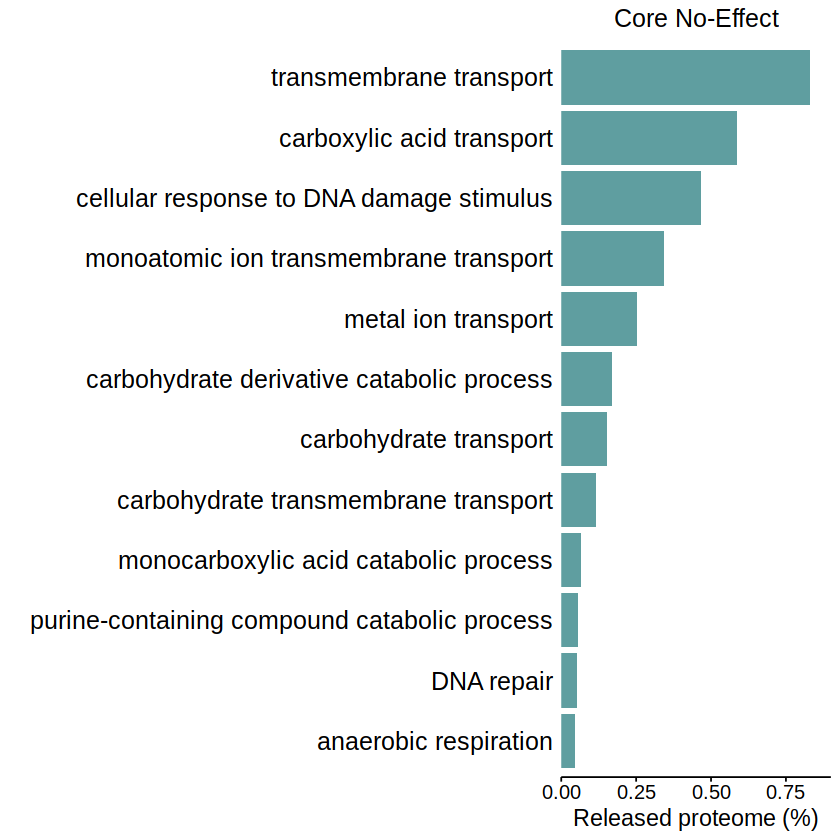

In [16]:
p <- ggplot(df_PFsorted, aes(x = FP, y = reorder(Process, FP))) +
    geom_bar(stat = "identity", fill = "cadetblue") +
    labs(x = "Released proteome (%)", y = "", title = "Core No-Effect") +
    theme_minimal() +
    theme(
        panel.background = element_blank(),
        plot.background = element_blank(),  
        axis.text.y = element_text(size = 15, colour = "black"),  # Increase y-axis text size
        axis.text.x = element_text(size = 12, colour = "black"),  # Increase x-axis text size
        axis.title.x = element_text(size = 14, colour = "black"), # Increase x-axis label size
        plot.title = element_text(size = 15, hjust = 0.5, colour = "black"), # Title size and center alignment
        panel.grid.major = element_blank(), # Remove major grid lines
        panel.grid.minor = element_blank(), # Remove minor grid lines
        panel.border = element_blank(), # Remove panel borders
        axis.line.x = element_line(color = "black"),            
        axis.ticks.x = element_line(color = "black")            
    ) +
    scale_x_continuous(limits = c(0, 0.9), expand = c(0, 0))

print(p)

# Adjust the dimensions
ggsave("./Figures/Fig5a_PFcore_noeff_46cond.png", p, width = 10, height = 6)
ggsave("./Figures/Fig5a_PFcore_noeff_46cond.svg", p, width = 10, height = 6)